In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)



In [5]:
df = pd.read_csv("fraudTest.csv")

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 555719
Number of columns: 23


In [7]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [8]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [10]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [11]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["is_fraud"].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [14]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64

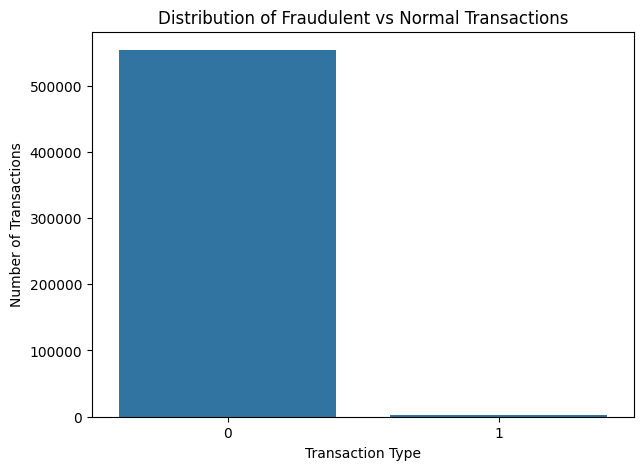

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="is_fraud")

plt.title("Distribution of Fraudulent vs Normal Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

In [16]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [17]:
df.shape

(555719, 22)

In [18]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

In [19]:
df[["trans_date_trans_time", "dob"]].dtypes

trans_date_trans_time    datetime64[ns]
dob                      datetime64[ns]
dtype: object

In [20]:
df.groupby("is_fraud")["amt"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,553574.0,67.614408,152.471931,1.00,9.60,47.15,82.62,22768.11
1,2145.0,528.356494,392.747594,1.78,214.51,371.94,907.77,1320.92


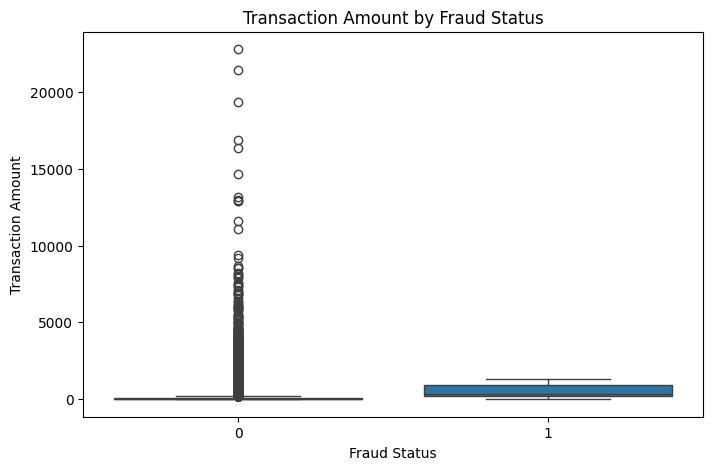

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="is_fraud", y="amt")

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")

plt.show()

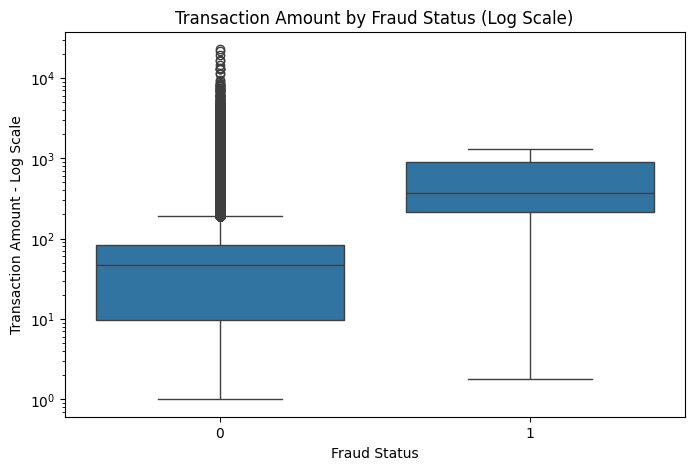

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="is_fraud", y="amt")

plt.yscale("log")

plt.title("Transaction Amount by Fraud Status (Log Scale)")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount - Log Scale")

plt.show()

In [23]:
category_fraud = pd.crosstab(
    df["category"],
    df["is_fraud"],
    normalize="index"
) * 100

category_fraud

is_fraud,0,1
category,,
entertainment,99.852883,0.147117
food_dining,99.862483,0.137517
gas_transport,99.726805,0.273195
grocery_net,99.788943,0.211057
grocery_pos,99.077122,0.922878
health_fitness,99.858210,0.141790
home,99.872003,0.127997
kids_pets,99.866508,0.133492
misc_net,99.024372,0.975628


In [24]:
fraud_by_category = category_fraud[1].sort_values(ascending=False)

fraud_by_category

category
shopping_net      1.211135
misc_net          0.975628
grocery_pos       0.922878
shopping_pos      0.427788
gas_transport     0.273195
travel            0.229239
grocery_net       0.211057
misc_pos          0.208249
personal_care     0.177995
entertainment     0.147117
health_fitness    0.141790
food_dining       0.137517
kids_pets         0.133492
home              0.127997
Name: 1, dtype: float64

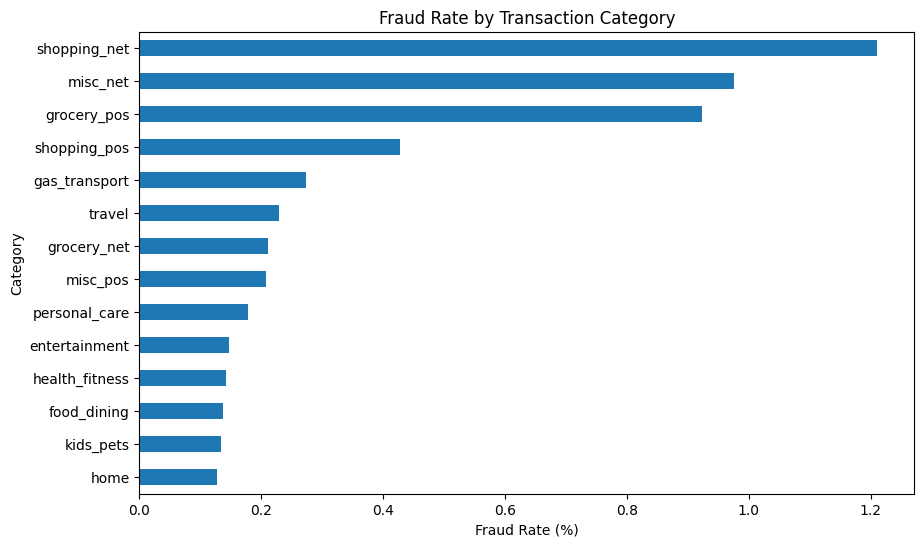

In [25]:
plt.figure(figsize=(10, 6))

fraud_by_category.sort_values().plot(kind="barh")

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Category")

plt.show()

In [26]:
gender_fraud = pd.crosstab(
    df["gender"],
    df["is_fraud"],
    normalize="index"
) * 100

gender_fraud

is_fraud,0,1
gender,,
F,99.618218,0.381782
M,99.608903,0.391097


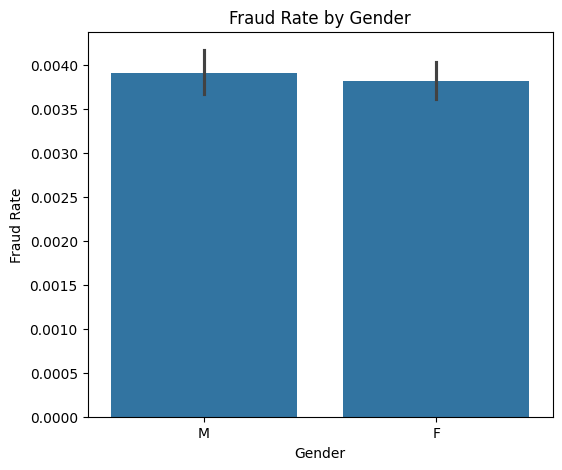

In [27]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=df,
    x="gender",
    y="is_fraud",
    estimator="mean"
)

plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate")

plt.show()

In [28]:
df["hour"] = df["trans_date_trans_time"].dt.hour

In [29]:
hour_fraud = df.groupby("hour")["is_fraud"].mean() * 100

In [30]:
hour_fraud

hour
0     1.035641
1     0.915443
2     0.926130
3     1.065993
4     0.082988
5     0.111626
6     0.077322
7     0.088408
8     0.055577
9     0.077580
10    0.066486
11    0.093985
12    0.060634
13    0.049684
14    0.049638
15    0.074872
16    0.073522
17    0.057013
18    0.107139
19    0.085944
20    0.128650
21    0.095728
22    1.937438
23    1.868185
Name: is_fraud, dtype: float64

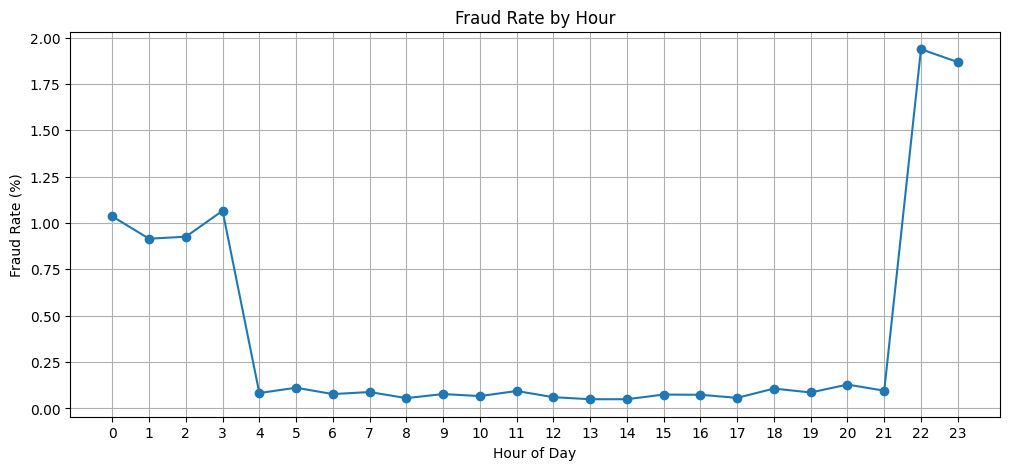

In [31]:
plt.figure(figsize=(12, 5))

hour_fraud.plot(kind="line", marker="o")

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.grid()
plt.show()

In [32]:
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek

In [33]:
day_fraud = df.groupby("day_of_week")["is_fraud"].mean() * 100
day_fraud

day_of_week
0    0.262298
1    0.300600
2    0.503407
3    0.519712
4    0.472885
5    0.427172
6    0.401727
Name: is_fraud, dtype: float64

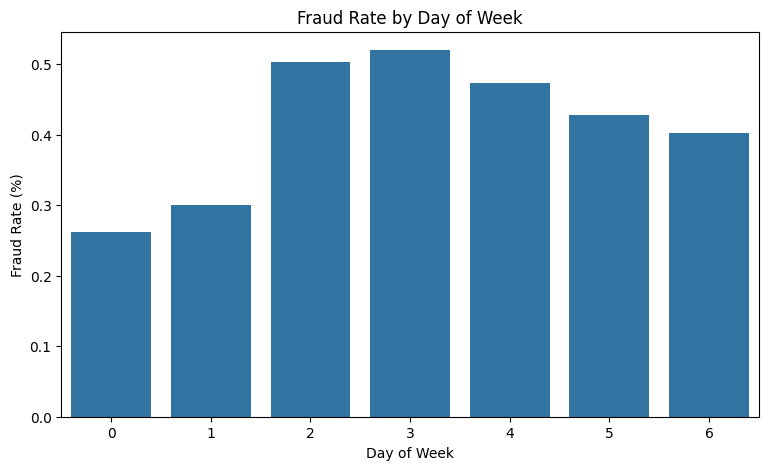

In [34]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=day_fraud.index,
    y=day_fraud.values
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [35]:
state_fraud = (
    df.groupby("state")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

In [36]:
state_fraud.head(15)

state
AK    1.660735
CT    1.220629
ID    0.883534
HI    0.825688
MT    0.732383
DC    0.659196
IN    0.627143
OR    0.614518
MS    0.611344
VA    0.599712
AZ    0.587979
IA    0.583806
NH    0.579878
NM    0.555556
KY    0.535743
Name: is_fraud, dtype: float64

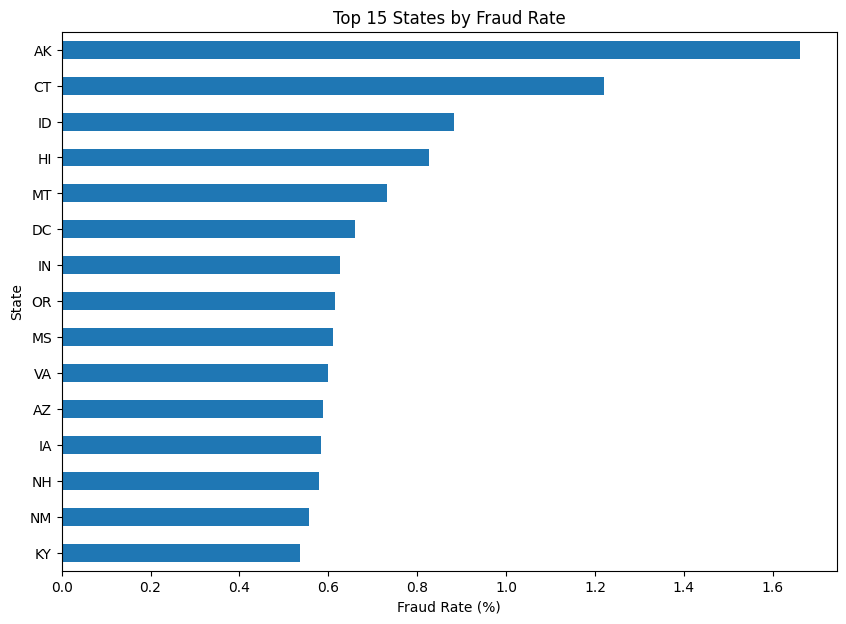

In [38]:
plt.figure(figsize=(10, 7))

state_fraud.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 States by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("State")

plt.show()

In [39]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

In [40]:
df["distance_km"] = haversine_distance(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

In [41]:
df["distance_km"].describe()

count    555719.000000
mean         76.104902
std          29.117079
min           0.123883
25%          55.286255
50%          78.179517
75%          98.520760
max         150.922504
Name: distance_km, dtype: float64

In [42]:
df.groupby("is_fraud")["distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,553574.0,76.104480,29.116533,0.123883,55.286175,78.178918,98.521159,150.922504
1,2145.0,76.213905,29.264066,3.839619,55.293105,78.593368,98.422515,142.849901


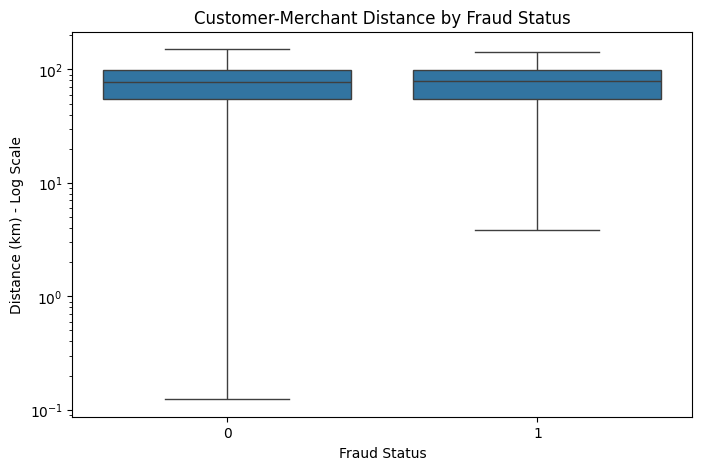

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="distance_km"
)

plt.yscale("log")

plt.title("Customer-Merchant Distance by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Distance (km) - Log Scale")

plt.show()

In [44]:
df["age"] = (
    df["trans_date_trans_time"] - df["dob"]
).dt.days / 365.25

In [45]:
df["age"].describe()

count    555719.000000
mean         46.887987
std          17.431204
min          15.392197
25%          33.448323
50%          44.908966
75%          58.056126
max          96.169747
Name: age, dtype: float64

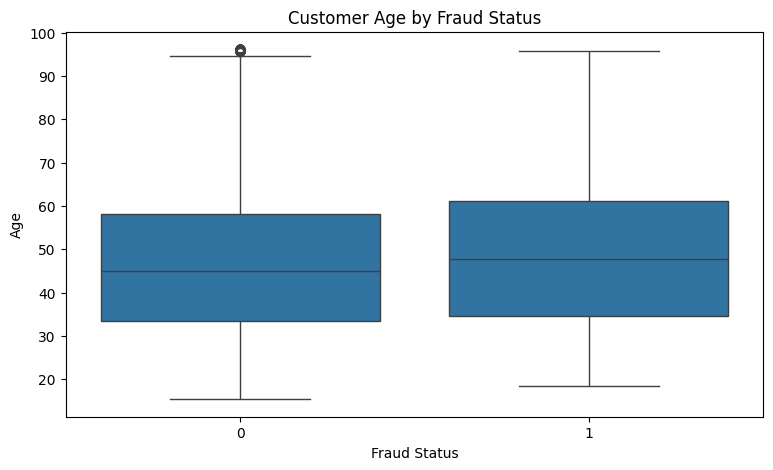

In [46]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="age"
)

plt.title("Customer Age by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Age")

plt.show()

In [47]:
drop_columns = [
    "first",
    "last",
    "street",
    "trans_num",
    "dob",
    "trans_date_trans_time",
    "cc_num",
    "unix_time"
]

df_model = df.drop(columns=drop_columns)

In [48]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   merchant     555719 non-null  object 
 1   category     555719 non-null  object 
 2   amt          555719 non-null  float64
 3   gender       555719 non-null  object 
 4   city         555719 non-null  object 
 5   state        555719 non-null  object 
 6   zip          555719 non-null  int64  
 7   lat          555719 non-null  float64
 8   long         555719 non-null  float64
 9   city_pop     555719 non-null  int64  
 10  job          555719 non-null  object 
 11  merch_lat    555719 non-null  float64
 12  merch_long   555719 non-null  float64
 13  is_fraud     555719 non-null  int64  
 14  hour         555719 non-null  int32  
 15  day_of_week  555719 non-null  int32  
 16  distance_km  555719 non-null  float64
 17  age          555719 non-null  float64
dtypes: float64(7), int32(2),

In [49]:
df["month"] = df["trans_date_trans_time"].dt.month
df["day"] = df["trans_date_trans_time"].dt.day

df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [50]:
df[
    [
        "trans_date_trans_time",
        "hour",
        "day_of_week",
        "month",
        "day",
        "is_weekend"
    ]
].head()

,trans_date_trans_time,hour,day_of_week,month,day,is_weekend
0,2020-06-21 12:14:25,12,6,6,21,1
1,2020-06-21 12:14:33,12,6,6,21,1
2,2020-06-21 12:14:53,12,6,6,21,1
3,2020-06-21 12:15:15,12,6,6,21,1
4,2020-06-21 12:15:17,12,6,6,21,1


In [51]:
df["log_amt"] = np.log1p(df["amt"])

df[["amt", "log_amt"]].head()

,amt,log_amt
0,2.86,1.350667
1,29.84,3.428813
2,41.28,3.744314
3,60.05,4.111693
4,3.19,1.432701


In [52]:
columns_to_drop = [
    "is_fraud",
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "trans_num",
    "cc_num",
    "unix_time"  
]

X = df.drop(columns=columns_to_drop)
y = df["is_fraud"]

In [53]:
X.head()

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,...,merch_lat,merch_long,hour,day_of_week,distance_km,age,month,day,is_weekend,log_amt
0,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,...,33.986391,-81.200714,12,6,24.561462,52.257358,6,21,1,1.350667
1,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,...,39.450498,-109.960431,12,6,104.925092,30.425736,6,21,1,3.428813
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,...,40.495810,-74.196111,12,6,59.080078,49.667351,6,21,1,3.744314
3,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,...,28.812398,-80.883061,12,6,27.698567,32.908966,6,21,1,4.111693
4,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,...,44.959148,-85.884734,12,6,104.335106,64.960986,6,21,1,1.432701


In [54]:
X.dtypes

merchant        object
category        object
amt            float64
gender          object
city            object
state           object
zip              int64
lat            float64
long           float64
city_pop         int64
job             object
merch_lat      float64
merch_long     float64
hour             int32
day_of_week      int32
distance_km    float64
age            float64
month            int32
day              int32
is_weekend       int64
log_amt        float64
dtype: object

In [55]:
numeric_features = [
    "amt",
    "log_amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "distance_km",
    "age",
    "hour",
    "day_of_week",
    "month",
    "day",
    "is_weekend"
]

In [56]:
categorical_features = [
    "category",
    "gender",
    "state",
]

In [57]:
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal selected features:", 
      len(numeric_features) + len(categorical_features))

Numeric features:
['amt', 'log_amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'distance_km', 'age', 'hour', 'day_of_week', 'month', 'day', 'is_weekend']

Categorical features:
['category', 'gender', 'state']

Total selected features: 17


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain fraud rate:")
print(y_train.mean())

print("\nTest fraud rate:")
print(y_test.mean())

X_train: (444575, 21)
X_test: (111144, 21)

Train fraud rate:
0.003859866164314233

Test fraud rate:
0.003859857482185273


In [60]:
X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]

X_train_cat = X_train[categorical_features]
X_test_cat = X_test[categorical_features]

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)


In [62]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_test_cat_encoded = encoder.transform(X_test_cat)

In [63]:
print("Numeric shape:", X_train_num_scaled.shape)
print("Categorical shape:", X_train_cat_encoded.shape)

Numeric shape: (444575, 14)
Categorical shape: (444575, 66)


In [64]:
X_train_processed = np.hstack([
    X_train_num_scaled,
    X_train_cat_encoded
])

X_test_processed = np.hstack([
    X_test_num_scaled,
    X_test_cat_encoded
])

In [65]:
print("Final X_train shape:", X_train_processed.shape)
print("Final X_test shape:", X_test_processed.shape)

Final X_train shape: (444575, 80)
Final X_test shape: (111144, 80)


In [66]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [67]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [68]:
y_pred = logistic_model.predict(X_test_processed)

y_prob = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [69]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))

Accuracy : 0.9101346001583531
Precision: 0.033570801210110274
Recall   : 0.8018648018648019
F1 Score : 0.06444361183964031
ROC-AUC  : 0.9479138513415711
PR-AUC   : 0.15156521596892603


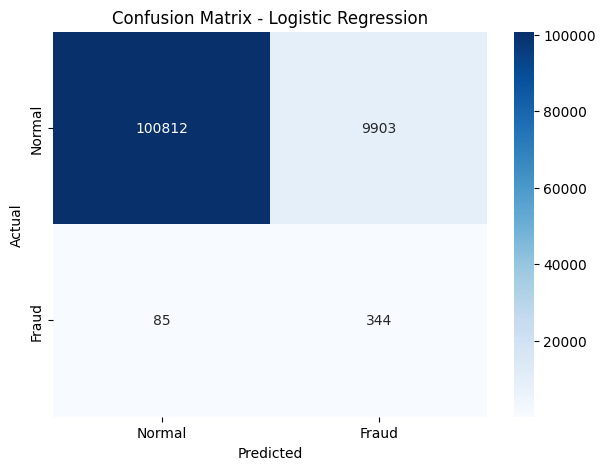

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

In [72]:
rf_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [73]:
rf_pred = rf_model.predict(X_test_processed)

rf_prob = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [74]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))
print("PR-AUC   :", average_precision_score(y_test, rf_prob))

Accuracy : 0.9987043835024833
Precision: 0.9797979797979798
Recall   : 0.6783216783216783
F1 Score : 0.8016528925619835
ROC-AUC  : 0.9989119567902931
PR-AUC   : 0.9072065404097416


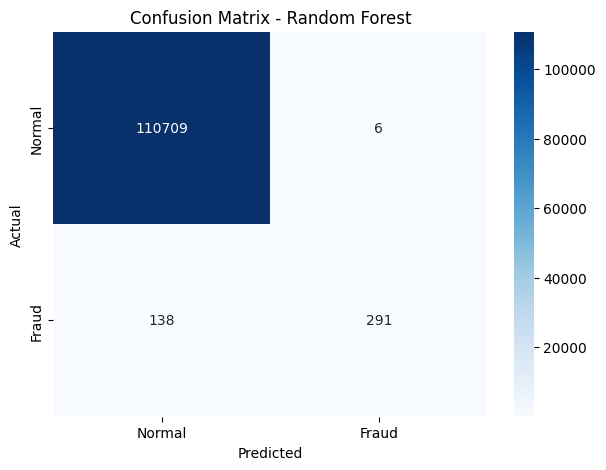

In [75]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [76]:
import xgboost as xgb

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative:", negative_count)
print("Positive:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative: 442859
Positive: 1716
scale_pos_weight: 258.0763403263403


In [77]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [78]:
xgb_model.fit(
    X_train_processed,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [79]:
xgb_pred = xgb_model.predict(X_test_processed)

xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [80]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))
print("PR-AUC   :", average_precision_score(y_test, xgb_prob))

Accuracy : 0.9981375512848197
Precision: 0.6868686868686869
Recall   : 0.951048951048951
F1 Score : 0.7976539589442815
ROC-AUC  : 0.99816374746601
PR-AUC   : 0.9495084777000624


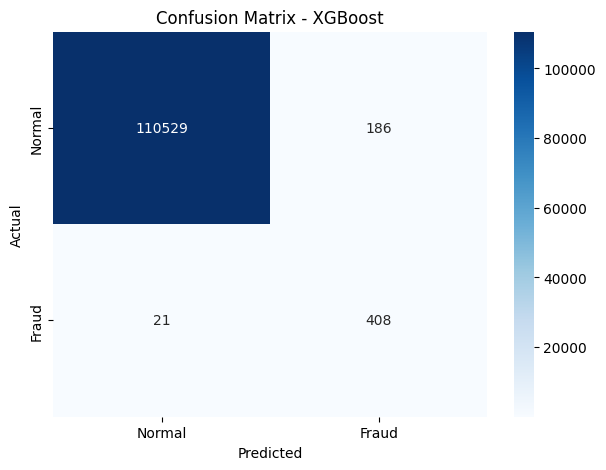

In [81]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [82]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    110715
       Fraud       0.69      0.95      0.80       429

    accuracy                           1.00    111144
   macro avg       0.84      0.97      0.90    111144
weighted avg       1.00      1.00      1.00    111144



In [83]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.910135,0.033571,0.801865,0.064444,0.947914,0.151565
1,Random Forest,0.998704,0.979798,0.678322,0.801653,0.998912,0.907207
2,XGBoost,0.998138,0.686869,0.951049,0.797654,0.998164,0.949508


In [84]:
results.sort_values(
    by="PR-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,XGBoost,0.998138,0.686869,0.951049,0.797654,0.998164,0.949508
1,Random Forest,0.998704,0.979798,0.678322,0.801653,0.998912,0.907207
0,Logistic Regression,0.910135,0.033571,0.801865,0.064444,0.947914,0.151565


In [85]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for threshold in thresholds:
    
    predictions = (xgb_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.1,0.327600,0.976690,0.490632
1,0.2,0.445161,0.965035,0.609272
2,0.3,0.545575,0.962704,0.696459
3,0.4,0.630368,0.958042,0.760407
4,0.5,0.686869,0.951049,0.797654


In [87]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

best_f1 = threshold_df["F1"].max()

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.5
Best F1: 0.7976539589442815


In [88]:
xgb_pred_tuned = (
    xgb_prob >= best_threshold
).astype(int)

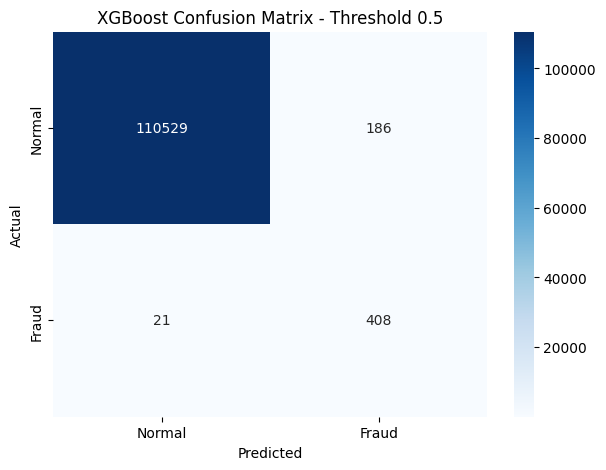

In [89]:
cm_tuned = confusion_matrix(
    y_test,
    xgb_pred_tuned
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"XGBoost Confusion Matrix - Threshold {best_threshold}"
)

plt.show()

In [90]:
print(
    classification_report(
        y_test,
        xgb_pred_tuned,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    110715
       Fraud       0.69      0.95      0.80       429

    accuracy                           1.00    111144
   macro avg       0.84      0.97      0.90    111144
weighted avg       1.00      1.00      1.00    111144



In [91]:
print("Precision:", precision_score(y_test, xgb_pred_tuned))
print("Recall   :", recall_score(y_test, xgb_pred_tuned))
print("F1 Score :", f1_score(y_test, xgb_pred_tuned))

Precision: 0.6868686868686869
Recall   : 0.951048951048951
F1 Score : 0.7976539589442815


In [92]:
results.sort_values(
    by="PR-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,XGBoost,0.998138,0.686869,0.951049,0.797654,0.998164,0.949508
1,Random Forest,0.998704,0.979798,0.678322,0.801653,0.998912,0.907207
0,Logistic Regression,0.910135,0.033571,0.801865,0.064444,0.947914,0.151565


In [93]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    y_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

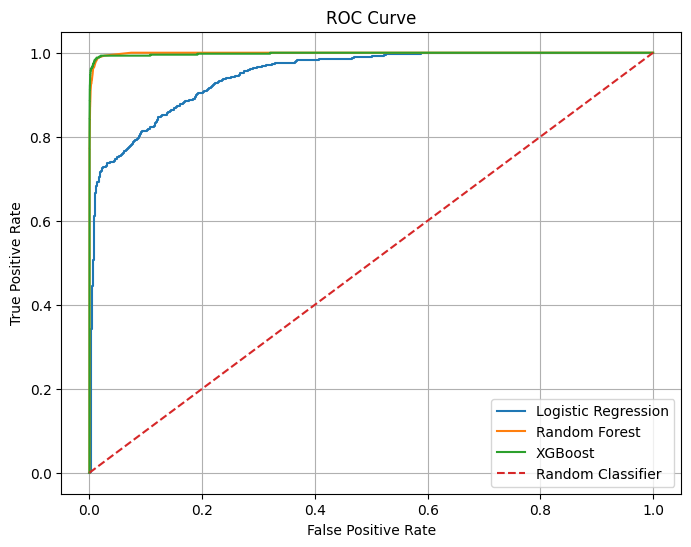

In [94]:
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [95]:
from sklearn.metrics import precision_recall_curve

lr_precision, lr_recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_prob
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test,
    xgb_prob
)

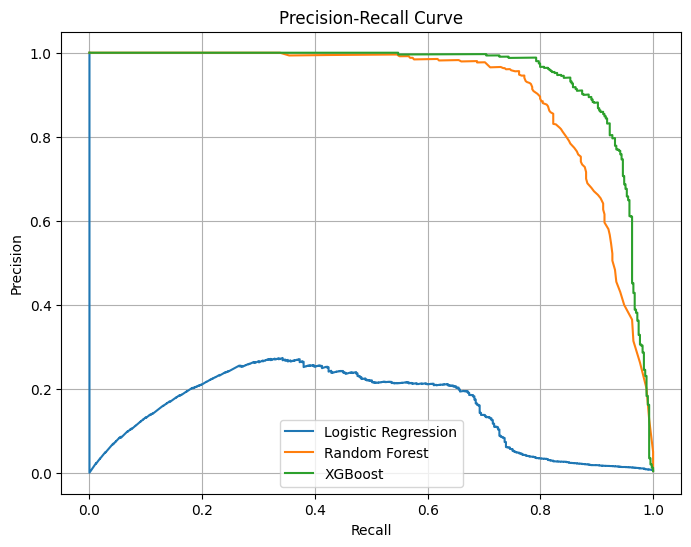

In [96]:
plt.figure(figsize=(8, 6))

plt.plot(
    lr_recall,
    lr_precision,
    label="Logistic Regression"
)

plt.plot(
    rf_recall,
    rf_precision,
    label="Random Forest"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()

In [97]:
results.sort_values(
    by="PR-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,XGBoost,0.998138,0.686869,0.951049,0.797654,0.998164,0.949508
1,Random Forest,0.998704,0.979798,0.678322,0.801653,0.998912,0.907207
0,Logistic Regression,0.910135,0.033571,0.801865,0.064444,0.947914,0.151565


In [98]:
import joblib

model_data = {
    "model": xgb_model,
    "scaler": scaler,
    "encoder": encoder,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "threshold": best_threshold
}

In [99]:
joblib.dump(
    model_data,
    "fraud_detection_model.pkl"
)

['fraud_detection_model.pkl']

In [101]:
def predict_transaction(transaction):
    
    # Convert dates
    transaction["trans_date_trans_time"] = pd.to_datetime(
        transaction["trans_date_trans_time"]
    )
    
    transaction["dob"] = pd.to_datetime(
        transaction["dob"]
    )
    
    # -----------------------------
    # Feature Engineering
    # -----------------------------
    
    transaction["hour"] = (
        transaction["trans_date_trans_time"].dt.hour
    )
    
    transaction["day_of_week"] = (
        transaction["trans_date_trans_time"].dt.dayofweek
    )
    
    transaction["month"] = (
        transaction["trans_date_trans_time"].dt.month
    )
    
    transaction["day"] = (
        transaction["trans_date_trans_time"].dt.day
    )
    
    transaction["is_weekend"] = (
        transaction["day_of_week"].isin([5, 6])
        .astype(int)
    )
    
    transaction["age"] = (
        transaction["trans_date_trans_time"]
        - transaction["dob"]
    ).dt.days / 365.25
    
    transaction["log_amt"] = np.log1p(
        transaction["amt"]
    )
    
    transaction["distance_km"] = haversine_distance(
        transaction["lat"],
        transaction["long"],
        transaction["merch_lat"],
        transaction["merch_long"]
    )
    
    # -----------------------------
    # Select Features
    # -----------------------------
    
    numeric_data = transaction[
        numeric_features
    ]
    
    categorical_data = transaction[
        categorical_features
    ]
    
    # -----------------------------
    # Preprocessing
    # -----------------------------
    
    numeric_scaled = scaler.transform(
        numeric_data
    )
    
    categorical_encoded = encoder.transform(
        categorical_data
    )
    
    # -----------------------------
    # Combine
    # -----------------------------
    
    processed_data = np.hstack([
        numeric_scaled,
        categorical_encoded
    ])
    
    # -----------------------------
    # Prediction Probability
    # -----------------------------
    
    probability = xgb_model.predict_proba(
        processed_data
    )[:, 1][0]
    
    # -----------------------------
    # Apply Threshold
    # -----------------------------
    
    prediction = int(
        probability >= best_threshold
    )
    
    return prediction, probability

In [106]:
new_transaction = pd.DataFrame([{
    "trans_date_trans_time": "2026-09-15 14:30:00",
    "dob": "1990-05-10",
    "amt": 250.50,
    "city_pop": 50000,
    "lat": 40.7128,
    "long": -74.0060,
    "merch_lat": 40.7306,
    "merch_long": -73.9352,
    "category": "shopping_pos",
    "gender": "M",
    "state": "NY"
}])

In [107]:
prediction, probability = predict_transaction(
    new_transaction
)

In [110]:
print("Fraud Probability:", probability)
print("Prediction:", prediction)

if prediction == 1:
    print("🚨 Fraudulent Transaction")
else:
    print("✅ Normal Transaction")

Fraud Probability: 0.00017630178
Prediction: 0
✅ Normal Transaction


In [111]:
print(
    f"Fraud Probability: {probability * 100:.2f}%"
)

Fraud Probability: 0.02%


In [ ]:
def predict_transaction(transaction):
    
    transaction["trans_date_trans_time"] = pd.to_datetime(
        transaction["trans_date_trans_time"]
    )
    
    transaction["dob"] = pd.to_datetime(
        transaction["dob"]
    )
    
    transaction["hour"] = (
        transaction["trans_date_trans_time"].dt.hour
    )
    
    transaction["day_of_week"] = (
        transaction["trans_date_trans_time"].dt.dayofweek
    )
    
    transaction["month"] = (
        transaction["trans_date_trans_time"].dt.month
    )
    
    transaction["day"] = (
        transaction["trans_date_trans_time"].dt.day
    )
    
    transaction["is_weekend"] = (
        transaction["day_of_week"].isin([5, 6])
        .astype(int)
    )
    
    transaction["age"] = (
        transaction["trans_date_trans_time"]
        - transaction["dob"]
    ).dt.days / 365.25
    
    transaction["log_amt"] = np.log1p(
        transaction["amt"]
    )
    
    transaction["distance_km"] = haversine_distance(
        transaction["lat"],
        transaction["long"],
        transaction["merch_lat"],
        transaction["merch_long"]
    )
    
    numeric_data = transaction[numeric_features]
    categorical_data = transaction[categorical_features]
    
    numeric_scaled = scaler.transform(
        numeric_data
    )
    
    categorical_encoded = encoder.transform(
        categorical_data
    )
    
    processed_data = np.hstack([
        numeric_scaled,
        categorical_encoded
    ])
    
    probability = xgb_model.predict_proba(
        processed_data
    )[:, 1][0]
    
    prediction = int(
        probability >= best_threshold
    )
    
    result = "Fraud" if prediction == 1 else "Normal"
    
    return result, probability